In [ ]:
%pip install pandas matplotlib
# pip install -e "D:\code-repo\Chomo\chronos-forecasting"
# or pip install chronos-forecasting

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu129

In [1]:
import os
import sys
print(sys.path)

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import chronos as chronos
print ("Chronos version:", chronos.__version__)

['C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env', '', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env\\Lib\\site-packages', 'D:\\code-repo\\Chomo\\chronos-forecasting\\src']


d:\code-repo\Chomo\chronos-forecasting\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chronos version: 2.0.0


In [2]:
# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# ETT-small Dataset

ground truth head 5 of future_targets:
                      date    HUFL   HULL    MUFL   MULL   LUFL   LULL     OT  \
17356  2018-06-24 04:00:00  14.133  5.626   9.737  3.482  4.477  1.310  6.964   
17357  2018-06-24 05:00:00  15.740  5.760  10.163  2.914  5.391  1.675  6.894   
17358  2018-06-24 06:00:00  13.731  4.957   8.244  2.025  5.483  1.736  7.457   
17359  2018-06-24 07:00:00   9.042  5.425   3.305  3.056  5.391  1.767  7.457   
17360  2018-06-24 08:00:00   3.617  5.760  -1.883  3.305  5.604  2.071  8.442   

       item_id  
17356        1  
17357        1  
17358        1  
17359        1  
17360        1  


head 5 of pred_df:
   item_id                date target_name  predictions       0.2       0.5  \
0        1 2018-06-24 04:00:00          OT     6.667579  6.431971  6.667579   
1        1 2018-06-24 05:00:00          OT     6.629655  6.349593  6.629655   
2        1 2018-06-24 06:00:00          OT     6.723119  6.347274  6.723119   
3        1 2018-06-24 07:00:00     

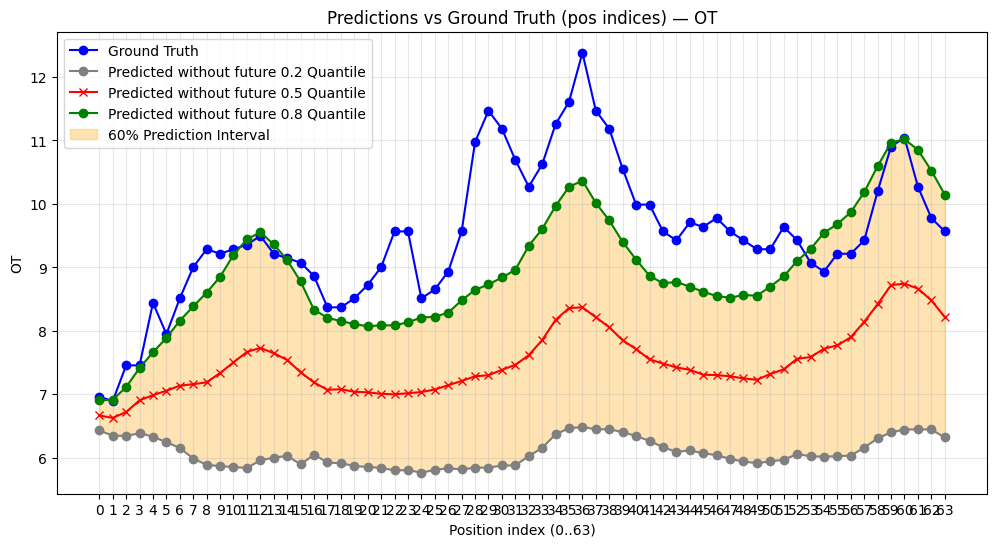

In [6]:
# Load raw data
context_df = pd.read_csv("./rawData/long_term_forecast/ETT-small/ETTh1.csv")

# Set column names
id_column = "item_id"
timestamp_column = "date"
return_targets = ["OT"]
quantile_levels=[0.2, 0.5, 0.8]
prediction_length = 64

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

# Separate input and output rows
context_input = context_df[:-prediction_length] # assuming last prediction_length rows are to be predicted
future_targets = context_df[-prediction_length:]
print("ground truth head 5 of future_targets:")
print(future_targets.head(5))
print("\n")

# ---------------------- Step 1: predit without future covariates ------------------------------
# Make predictions
pred_df = pipeline.predict_df(
    context_input,
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=return_targets,
)
print("head 5 of pred_df:")
print(pred_df.head(5))
print("\n")

# compute the quantile bands between 0.2 and 0.8, float32
pred_df['quantile_band_0.2_0.8'] = (pred_df['0.8'] - pred_df['0.2']).astype(np.float32)


# ---------------------- Visualization ------------------------------
# Plot each return target with median and 0.2/0.8 quantiles
qcols = [f"{q:.1f}" for q in quantile_levels]
n = prediction_length
future_short = future_targets.iloc[:n].copy()
pred_without_future = pred_df.copy().reset_index(drop=True).iloc[:n].copy()

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_without_future['pos'] = x

# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

for target in return_targets:
    # check quantile columns
    for q in qcols:
        if q not in pred_without_future.columns:
            print(f'Quantile column {q} for {target} not found in pred_without_future; available columns: {list(pred_without_future.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # i) Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # ii) Predicted without future quantiles
    plt.plot(x, pred_without_future[qcols[0]].values, label='Predicted without future 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_without_future[qcols[1]].values, label='Predicted without future 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_without_future[qcols[2]].values, label='Predicted without future 0.8 Quantile', color='green', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_without_future[qcols[0]].values, pred_without_future[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [7]:

# ---------------------- Step 2: predit with future covariates ------------------------------
# Add a 'quantile_band_0.2_0.8' column to context_input, with all nan values
context_input_with_band = context_input.reset_index(drop=True).copy()
context_input_with_band['quantile_band_0.2_0.8'] = np.float32(np.nan)

# build future_df with id column, a timestamp, and 'quantile_band_0.2_0.8'
future_df_with_band = future_targets[[id_column, timestamp_column]].copy()
future_df_with_band = future_df_with_band.reset_index(drop=True).iloc[:prediction_length]
future_df_with_band['quantile_band_0.2_0.8'] = pred_df['quantile_band_0.2_0.8'].reset_index(drop=True).iloc[:prediction_length].values

# make predictions with future covariates
pred_df_with_future = pipeline.predict_df(
    df        = context_input_with_band,
    future_df = future_df_with_band,
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=return_targets,
)
print("head 5 of pred_df_with_future:")
print(pred_df_with_future.head(5))

head 5 of pred_df_with_future:
   item_id                date target_name  predictions       0.2       0.5  \
0        1 2018-06-24 04:00:00          OT     6.668120  6.444487  6.668120   
1        1 2018-06-24 05:00:00          OT     6.643326  6.379268  6.643326   
2        1 2018-06-24 06:00:00          OT     6.754700  6.405576  6.754700   
3        1 2018-06-24 07:00:00          OT     6.951088  6.479738  6.951088   
4        1 2018-06-24 08:00:00          OT     7.041508  6.427038  7.041508   

        0.8  
0  6.895145  
1  6.901742  
2  7.120700  
3  7.412673  
4  7.666951  


future_short(ground truth) shape: (64, 9)
pred_without_future shape: (64, 8)
pred_with_future shape: (64, 7)
Position -> future_targets original [(0, '2018-06-24 04:00:00'), (1, '2018-06-24 05:00:00'), (2, '2018-06-24 06:00:00'), (3, '2018-06-24 07:00:00'), (4, '2018-06-24 08:00:00'), (5, '2018-06-24 09:00:00'), (6, '2018-06-24 10:00:00'), (7, '2018-06-24 11:00:00'), (8, '2018-06-24 12:00:00'), (9, '2018-06-24 13:00:00'), (10, '2018-06-24 14:00:00'), (11, '2018-06-24 15:00:00'), (12, '2018-06-24 16:00:00'), (13, '2018-06-24 17:00:00'), (14, '2018-06-24 18:00:00'), (15, '2018-06-24 19:00:00'), (16, '2018-06-24 20:00:00'), (17, '2018-06-24 21:00:00'), (18, '2018-06-24 22:00:00'), (19, '2018-06-24 23:00:00'), (20, '2018-06-25 00:00:00'), (21, '2018-06-25 01:00:00'), (22, '2018-06-25 02:00:00'), (23, '2018-06-25 03:00:00'), (24, '2018-06-25 04:00:00'), (25, '2018-06-25 05:00:00'), (26, '2018-06-25 06:00:00'), (27, '2018-06-25 07:00:00'), (28, '2018-06-25 08:00:00'), (29, '2018-06-25 09:00:

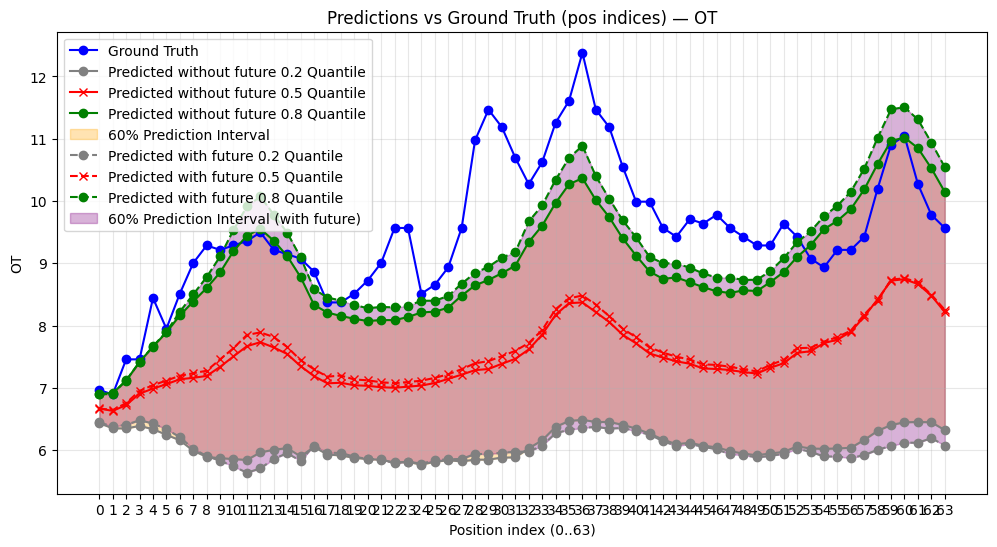

In [4]:
# ---------------------- Step 3: compare 2 prediction results ------------------------------
# plot Ground truth vs pred_df vs pred_df_with_future for a selected id
qcols = [f"{q:.1f}" for q in quantile_levels]
n = prediction_length

# Take first n rows of the held-out future targets (ground truth) and predictions
future_short = future_targets.iloc[:n].copy()
pred_without_future = pred_df.copy().reset_index(drop=True).iloc[:n].copy()
pred_with_future = pred_df_with_future.copy().reset_index(drop=True).iloc[:n].copy()
print("future_short(ground truth) shape:", future_short.shape)
print("pred_without_future shape:", pred_without_future.shape)
print("pred_with_future shape:", pred_with_future.shape)

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_without_future['pos'] = x
pred_with_future['pos'] = x

# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

# Plot each return target with median and 0.2/0.8 quantiles
for target in return_targets:
    # check quantile columns
    for q in qcols:
        if q not in pred_without_future.columns:
            print(f'Quantile column {q} for {target} not found in pred_without_future; available columns: {list(pred_without_future.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # i) Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # ii) Predicted without future quantiles
    plt.plot(x, pred_without_future[qcols[0]].values, label='Predicted without future 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_without_future[qcols[1]].values, label='Predicted without future 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_without_future[qcols[2]].values, label='Predicted without future 0.8 Quantile', color='green', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_without_future[qcols[0]].values, pred_without_future[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    # iii) Predicted with future quantiles
    plt.plot(x, pred_with_future[qcols[0]].values, label='Predicted with future 0.2 Quantile', color='gray', marker='o', linestyle='--')
    plt.plot(x, pred_with_future[qcols[1]].values, label='Predicted with future 0.5 Quantile', color='red', marker='x', linestyle='--')
    plt.plot(x, pred_with_future[qcols[2]].values, label='Predicted with future 0.8 Quantile', color='green', marker='o', linestyle='--')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_with_future[qcols[0]].values, pred_with_future[qcols[2]].values, color='purple', alpha=0.3, label='60% Prediction Interval (with future)')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()